In [86]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# --- CORE DATA PROCESSING ---
import numpy as np
import pandas as pd
import shutil
import joblib

# --- MODELING & ENSEMBLES ---
import xgboost as xgb
from sklearn.linear_model import LassoCV
from sklearn.ensemble import VotingRegressor

# --- MODEL EVALUATION & VALIDATION ---
from sklearn.model_selection import (
    LeaveOneOut, 
    cross_val_score, 
    cross_val_predict, 
    learning_curve, 
    train_test_split
)

# --- PERFORMANCE METRICS ---
from sklearn.metrics import (
    r2_score, 
    mean_absolute_error, 
    mean_squared_error, 
    mean_absolute_percentage_error
)

# --- VISUALIZATION ---
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sanilawijesekara/yield-dataset-combined/yield_final.csv


In [87]:
work_dir = "/kaggle/working"

for filename in os.listdir(work_dir):
    file_path = os.path.join(work_dir, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print("Output directory cleaned!")

Output directory cleaned!


In [88]:
df_final = pd.read_csv("/kaggle/input/datasets/sanilawijesekara/yield-dataset-combined/yield_final.csv")
df_final.head()

,Unnamed: 0,district,year,pixel_id,veg_days,repro_days,peak_health,auc_health,avg_health,temp_flowering,...,PC4,PC5,District,Year,Season,Average_yield_kg_per_ha,Harvested_extent_ha,Total_production_MT,Season_ID,District_ID
0,0,Ampara,2022,1621.251272,106.539232,54.752582,0.901939,6.842034,-0.021292,-0.847574,...,-1.828828,0.825333,Ampara,2022,Maha,2857,77631,221529,0,0
1,1,Ampara,2022,1607.637649,64.594595,50.125707,0.945928,4.352596,-0.039154,0.235582,...,-0.908302,1.030039,Ampara,2022,Yala,3708,59869,221999,1,0
2,2,Ampara,2023,1623.185289,222.591554,124.489637,1.381839,14.947866,-0.006680,-0.897823,...,-0.527367,-0.128902,Ampara,2023,Maha,4172,76347,318517,0,0
3,3,Ampara,2023,1622.000000,133.217257,82.779661,1.332580,9.916422,0.024450,1.125715,...,-0.719562,0.079124,Ampara,2023,Yala,4338,60377,261938,1,0
4,4,Ampara,2024,1621.851589,248.327677,145.692687,1.476648,16.849490,-0.003016,-0.932013,...,-0.071171,-0.292757,Ampara,2024,Maha,3933,67898,267017,0,0


In [89]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               165 non-null    int64  
 1   district                 165 non-null    object 
 2   year                     165 non-null    int64  
 3   pixel_id                 165 non-null    float64
 4   veg_days                 165 non-null    float64
 5   repro_days               165 non-null    float64
 6   peak_health              165 non-null    float64
 7   auc_health               165 non-null    float64
 8   avg_health               165 non-null    float64
 9   temp_flowering           165 non-null    float64
 10  rain_flowering           165 non-null    float64
 11  stress_flowering         165 non-null    float64
 12  PC1                      165 non-null    float64
 13  PC2                      165 non-null    float64
 14  PC3                      1

In [90]:
# Create combined signals
df_final['heat_stress_combo'] = df_final['temp_flowering'] * df_final['stress_flowering']
df_final['health_per_day'] = df_final['auc_health'] / (df_final['veg_days'] + df_final['repro_days'])

# 1. Target Encoding: Give the model a "District Baseline" 
# This tells the model the typical yield for a district so it doesn't have to guess from scratch.
district_means = df_final.groupby('District_ID')['Average_yield_kg_per_ha'].mean()
df_final['district_historical_avg'] = df_final['District_ID'].map(district_means)

# 2. Interaction Features: Capture "The Double Whammy"
# High heat is worse when rain is low.
df_final['heat_rain_ratio'] = df_final['temp_flowering'] / (df_final['rain_flowering'] + 1.1) 
# Health efficiency: How much biomass is produced per day of the reproductive phase?
df_final['repro_efficiency'] = df_final['auc_health'] / (df_final['repro_days'] + 1)

# 5. Crisis Year Flag: 2021 and 2022 saw massive yield drops due to fertilizer bans/economic crisis.
# Satellite data might look okay, but the "bag weight" was lower.
df_final['crisis_year'] = df_final['Year'].apply(lambda x: 1 if x in [2021, 2022] else 0)

In [91]:
df_final.drop(columns = ['Unnamed: 0','year','Year','pixel_id','District','district','Season','Harvested_extent_ha','Total_production_MT'], inplace=True)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   veg_days                 165 non-null    float64
 1   repro_days               165 non-null    float64
 2   peak_health              165 non-null    float64
 3   auc_health               165 non-null    float64
 4   avg_health               165 non-null    float64
 5   temp_flowering           165 non-null    float64
 6   rain_flowering           165 non-null    float64
 7   stress_flowering         165 non-null    float64
 8   PC1                      165 non-null    float64
 9   PC2                      165 non-null    float64
 10  PC3                      165 non-null    float64
 11  PC4                      165 non-null    float64
 12  PC5                      165 non-null    float64
 13  Average_yield_kg_per_ha  165 non-null    int64  
 14  Season_ID                1

🔍 Evaluating model performance using Leave-One-Out Cross-Validation...
✅ Honest Average Error (MAE): 396.36 kg/ha
✅ Error Stability (Std Dev): ±315.77 kg/ha

🚀 Training final ensemble model on the full dataset...
💾 Ensemble model saved as 'rice_yield_ensemble_v2.pkl'


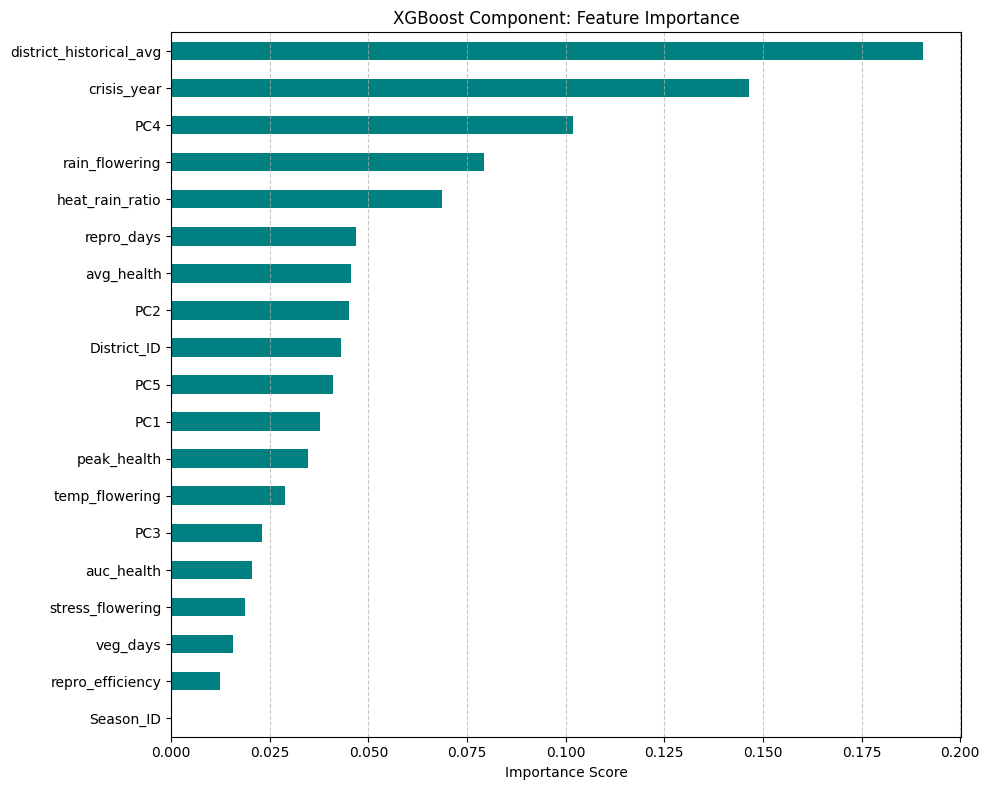

In [92]:
# Add these new columns to your 'features' list
# 1. SELECT NECESSARY COLUMNS
features = [
    'veg_days', 'repro_days', 'peak_health', 'auc_health', 'avg_health', 
    'temp_flowering', 'rain_flowering', 'stress_flowering', 
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 
    'Season_ID', 'District_ID', 
    'district_historical_avg', 'heat_rain_ratio', 'repro_efficiency', 'crisis_year'
]

target = 'Average_yield_kg_per_ha'

# Ensure the data is ready
X = df_final[features]
y = df_final[target]

# --- STEP 3: DEFINE THE ENSEMBLE MODEL ---
# XGBoost: Captures complex non-linear crop patterns
xgb_base = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=10,
    reg_lambda=20,
    random_state=42
)

# Lasso: A linear model that is very "sturdy" and prevents overfitting
lasso_base = LassoCV(cv=5)

# The Ensemble: They "vote" on the final prediction
yield_model = VotingRegressor([
    ('xgb', xgb_base),
    ('lasso', lasso_base)
])

# --- STEP 4: EVALUATE WITH LOOCV (The Ultimate Small-Data Test) ---
print("🔍 Evaluating model performance using Leave-One-Out Cross-Validation...")
loo = LeaveOneOut()
# Use n_jobs=-1 to use all CPU cores
cv_scores = cross_val_score(yield_model, X, y, cv=loo, scoring='neg_mean_absolute_error', n_jobs=-1)
mae_scores = -cv_scores

print(f"✅ Honest Average Error (MAE): {mae_scores.mean():.2f} kg/ha")
print(f"✅ Error Stability (Std Dev): ±{mae_scores.std():.2f} kg/ha")

# --- STEP 5: TRAIN FINAL MODEL ---
print("\n🚀 Training final ensemble model on the full dataset...")
yield_model.fit(X, y)

# --- STEP 6: SAVE THE MODEL ---
joblib.dump(yield_model, 'rice_yield_ensemble_v2.pkl')
print("💾 Ensemble model saved as 'rice_yield_ensemble_v2.pkl'")

# --- STEP 7: PLOT FEATURE IMPORTANCE (From the XGBoost component) ---
# Since VotingRegressor doesn't have feature_importances_, we pull them from the XGBoost part
plt.figure(figsize=(10, 8))
xgb_trained = yield_model.named_estimators_['xgb']
importances = pd.Series(xgb_trained.feature_importances_, index=features).sort_values(ascending=True)

importances.plot(kind='barh', color='teal')
plt.title("XGBoost Component: Feature Importance")
plt.xlabel("Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.066e+03, tolerance: 1.431e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.379e+03, tolerance: 1.934e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.602e+03, tolerance: 1.303e

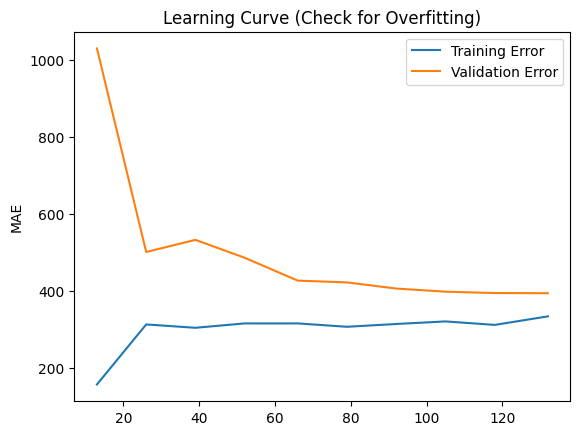

In [93]:
train_sizes, train_scores, test_scores = learning_curve(
    yield_model, X, y, cv=5, scoring='neg_mean_absolute_error', 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Validation Error')
plt.title('Learning Curve (Check for Overfitting)')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [94]:
# --- STEP 1: GENERATE HONEST PREDICTIONS (Out-of-Sample) ---
# We use LOOCV to get a prediction for every single row as if it were "new" data.
loo = LeaveOneOut()
y_pred_cv = cross_val_predict(yield_model, X, y, cv=loo, n_jobs=-1)

# --- STEP 2: CALCULATE PERFORMANCE METRICS ---

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    accuracy = 100 - mape
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape, "Accuracy": accuracy}

# Metrics on the data the model was TRAINED on (Fit quality)
train_metrics = calculate_metrics(y, yield_model.predict(X))

# Metrics on the data the model HAS NOT SEEN (Generalization quality)
val_metrics = calculate_metrics(y, y_pred_cv)

# --- STEP 3: PRINT THE FINAL REPORT ---
print("📊 --- FINAL MODEL PERFORMANCE REPORT --- 📊")
print(f"{'Metric':<15} | {'Training (Fit)':<18} | {'Validation (Honest)':<20}")
print("-" * 60)
for key in train_metrics:
    print(f"{key:<15} | {train_metrics[key]:>18.2f} | {val_metrics[key]:>20.2f}")

print("\n💡 INTERPRETATION:")
print(f"• Your Honest Accuracy is {val_metrics['Accuracy']:.2f}%.")
print(f"• Your R² is {val_metrics['R2']:.4f}, meaning you explain {val_metrics['R2']*100:.1f}% of yield variance.")

📊 --- FINAL MODEL PERFORMANCE REPORT --- 📊
Metric          | Training (Fit)     | Validation (Honest) 
------------------------------------------------------------
MAE             |             341.76 |               396.36
RMSE            |             436.70 |               506.77
R2              |               0.73 |                 0.64
MAPE            |              10.37 |                12.02
Accuracy        |              89.63 |                87.98

💡 INTERPRETATION:
• Your Honest Accuracy is 87.98%.
• Your R² is 0.6382, meaning you explain 63.8% of yield variance.


In [95]:
# Create a dataframe to analyze errors
results = X.copy()
results['Actual'] = y
results['Predicted'] = yield_model.predict(X)
results['Error'] = np.abs(results['Actual'] - results['Predicted'])

# Look at the top 10 biggest failures
biggest_errors = results.sort_values(by='Error', ascending=False).head(10)
print(biggest_errors[['District_ID','Season_ID', 'Actual', 'Predicted', 'Error']])

     District_ID  Season_ID  Actual    Predicted        Error
93            13          1    2184  3621.710361  1437.710361
5              0          1    5532  4376.440299  1155.559701
78            11          0    2005  3086.115273  1081.115273
79            11          1    4339  3372.906637   966.093363
94            13          0    4776  3831.744929   944.255071
135           19          1    5716  4778.944436   937.055564
156           22          1    5053  4129.100973   923.899027
159           23          1    4368  3473.607378   894.392622
91            13          1    4826  3964.113899   861.886101
158           23          0    2373  3213.733277   840.733277


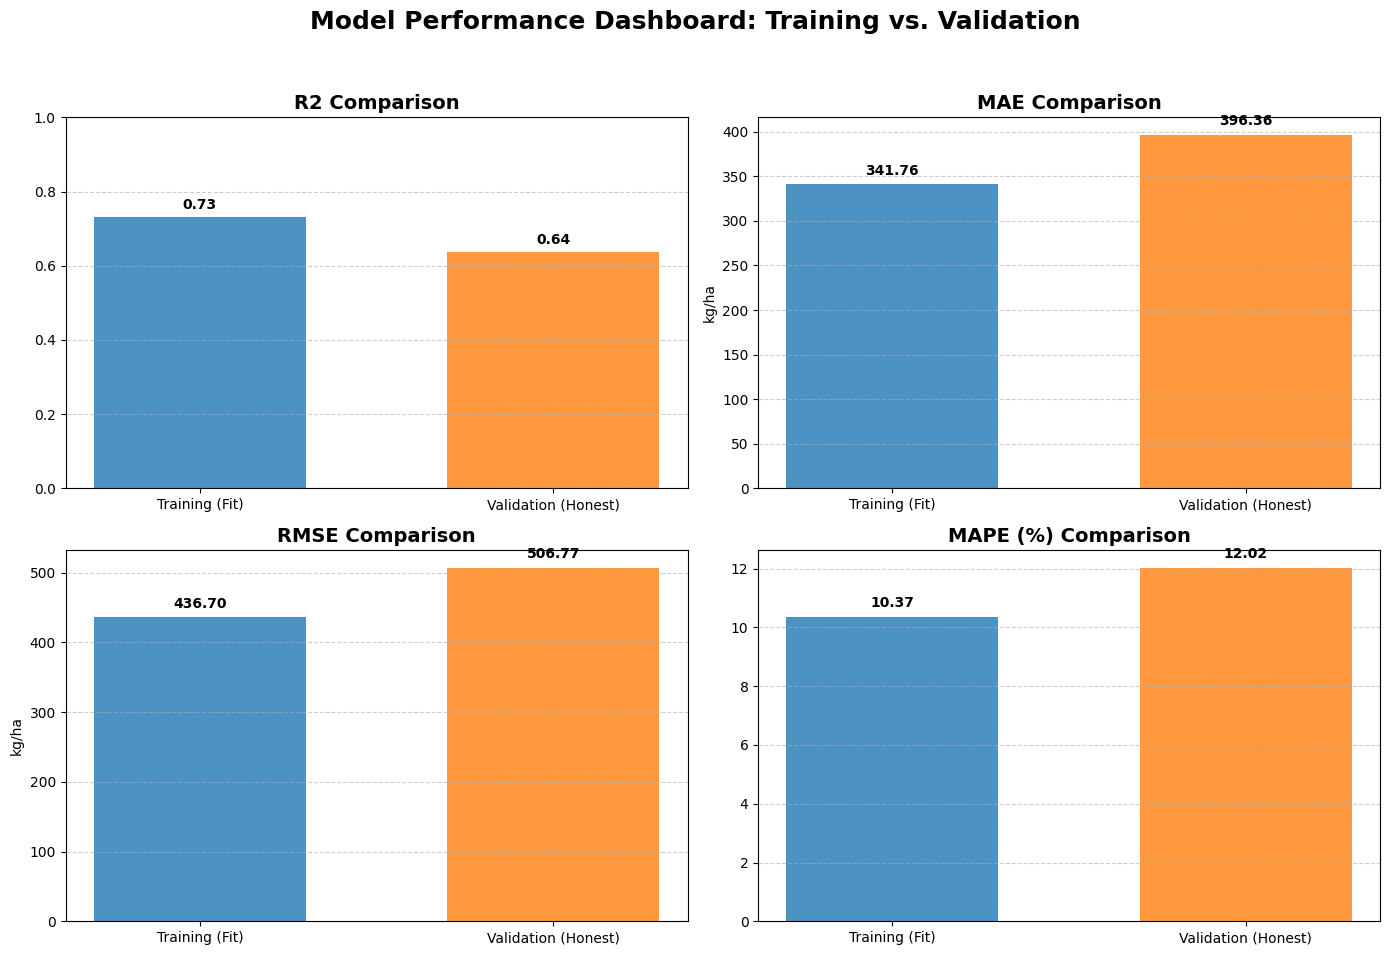

In [96]:
# --- 1. GENERATE THE DATA FOR THE PLOTS ---
loo = LeaveOneOut()
y_pred_train = yield_model.predict(X)
y_pred_cv = cross_val_predict(yield_model, X, y, cv=loo, n_jobs=-1)

def get_metrics_df(y_true, y_pred, label):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'MAPE (%)': mean_absolute_percentage_error(y_true, y_pred) * 100
    }

train_res = get_metrics_df(y, y_pred_train, 'Train')
val_res = get_metrics_df(y, y_pred_cv, 'Validation')

# --- 2. CREATE THE PLOT ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Dashboard: Training vs. Validation', fontsize=18, fontweight='bold')

metrics = ['R2', 'MAE', 'RMSE', 'MAPE (%)']
colors = ['#1f77b4', '#ff7f0e'] # Blue for Train, Orange for Val
labels = ['Training (Fit)', 'Validation (Honest)']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    
    # Data for the specific metric
    values = [train_res[metric], val_res[metric]]
    
    bars = ax.bar(labels, values, color=colors, alpha=0.8, width=0.6)
    
    # Adding titles and labels
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    if metric in ['MAE', 'RMSE']:
        ax.set_ylabel('kg/ha')
    elif metric == 'R2':
        ax.set_ylim(0, 1.0) # R2 is usually between 0 and 1
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (height*0.02),
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold')

    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('performance_metrics_dashboard.png')
plt.show()